In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Cell 1 — GPU + environment

In [2]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print("GPU allocator set.")

GPU allocator set.


Cell 2 — Dependencies

In [3]:
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'], check=True)

pip('mne', 'awscli', 'tensorflow', 'scikit-learn',
    'numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn')

print('Dependencies ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 26.6 MB/s eta 0:00:00
Dependencies ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
aiobotocore 3.3.0 requires botocore<1.42.71,>=1.42.62, but you have botocore 1.42.96 which is incompatible.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


Cell 3 — Paths

In [4]:
import os
from pathlib import Path

if os.path.exists('/content'):
    ENV, BASE = 'colab', Path('/content/sir-eegnet')
elif os.path.exists('/kaggle/working'):
    ENV, BASE = 'kaggle', Path('/kaggle/working/sir-eegnet')
else:
    ENV, BASE = 'local', Path.cwd().parent

DATA_DIR     = BASE / 'data'
DS_DIR       = DATA_DIR / 'ds004504'
DERIV_DIR    = DS_DIR / 'derivatives'
PARTICIPANTS = DS_DIR / 'participants.tsv'
RESULTS_DIR  = BASE / 'results'
MODELS_DIR   = BASE / 'saved_models'

for d in [DATA_DIR, DS_DIR, DERIV_DIR, RESULTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Environment : {ENV}')
print(f'Base        : {BASE}')

Environment : colab
Base        : /content/sir-eegnet


Cell 4 — Imports and seeds


In [5]:
import numpy as np
import pandas as pd
import gc
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense, Lambda
)
from tensorflow.keras.constraints import max_norm
import tensorflow.keras.backend as K

import mne
mne.set_log_level('WARNING')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from collections import Counter

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU devices: {tf.config.list_physical_devices("GPU")}')

2026-04-27 16:42:21.249462: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777308141.469947      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777308141.532343      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777308142.088396      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777308142.088435      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777308142.088438      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Cell 5 — Constants

In [6]:
# Signal parameters
SFREQ          = 500.0
N_CHANNELS     = 19
EPOCH_DURATION = 4.0
EPOCH_OVERLAP  = 0.5
EPOCH_SAMPLES  = int(EPOCH_DURATION * SFREQ)   # 2000

# Label maps
GROUP_MAP   = {'A': 0, 'F': 1, 'C': 2}
LABEL_NAMES = {0: 'AD', 1: 'FTD', 2: 'HC'}

# EEGNet architecture — Lawhern et al. 2018
# kern_length = SFREQ/2 as recommended in paper
KERN_LENGTH = 250
F1          = 8
D           = 2      # depth multiplier
DROPOUT     = 0.5

# SIR-EEGNet specific
GRL_LAMBDA  = 1.0    # gradient reversal strength
ALPHA       = 0.2    # subject loss weight in total loss

# Training — optimised for Kaggle T4 overnight batch
BATCH_SIZE          = 64
MAX_EPOCHS          = 50
PATIENCE            = 10
VAL_FRAC            = 0.10
MAX_EP_PER_SUBJECT  = 150   # cap epochs per subject — methodologically sound

print(f'Epoch shape         : ({N_CHANNELS}, {EPOCH_SAMPLES}, 1)')
print(f'kern_length         : {KERN_LENGTH}  (= SFREQ/2)')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Max training epochs : {MAX_EPOCHS} with patience={PATIENCE}')
print(f'GRL lambda          : {GRL_LAMBDA}')
print(f'Subject loss alpha  : {ALPHA}')
print(f'Max epochs/subject  : {MAX_EP_PER_SUBJECT}')

Epoch shape         : (19, 2000, 1)
kern_length         : 250  (= SFREQ/2)
Batch size          : 64
Max training epochs : 50 with patience=10
GRL lambda          : 1.0
Subject loss alpha  : 0.2
Max epochs/subject  : 150


Cell 6 — Download dataset

In [7]:
import subprocess

def download_ds004504(deriv_dir, participants_path):
    set_files = list(deriv_dir.rglob('*.set'))
    if participants_path.exists() and len(set_files) >= 80:
        print(f'Dataset present ({len(set_files)} .set files). Skipping download.')
        return
    print('Downloading ds004504 from OpenNeuro S3 (~2.7 GB)...')
    r1 = subprocess.run([
        'aws', 's3', 'sync',
        's3://openneuro.org/ds004504/derivatives/', str(deriv_dir),
        '--no-sign-request', '--region', 'us-east-1'
    ], capture_output=True, text=True)
    if r1.returncode != 0:
        raise RuntimeError(f'Download failed:\n{r1.stderr[-600:]}')
    r2 = subprocess.run([
        'aws', 's3', 'cp',
        's3://openneuro.org/ds004504/participants.tsv', str(participants_path),
        '--no-sign-request', '--region', 'us-east-1'
    ], capture_output=True, text=True)
    if r2.returncode != 0:
        raise RuntimeError(f'TSV failed:\n{r2.stderr[-600:]}')
    print('Download complete.')

download_ds004504(DERIV_DIR, PARTICIPANTS)

Download complete.


Cell 7 — Load participants

In [8]:
participants = pd.read_csv(PARTICIPANTS, sep='\t')
participants['label'] = participants['Group'].map(GROUP_MAP)
participants = participants.dropna(subset=['label'])
participants['label'] = participants['label'].astype(int)

print(f'Total subjects: {len(participants)}')
print()
for label, name in LABEL_NAMES.items():
    n = (participants['label'] == label).sum()
    print(f'  {name} (label={label}): {n} subjects')

Total subjects: 88

  AD (label=0): 36 subjects
  FTD (label=1): 23 subjects
  HC (label=2): 29 subjects


Cell 8 — Build subject metadata index

In [9]:
subject_meta = {}
failed       = []

for _, row in participants.iterrows():
    sid   = row['participant_id']
    label = int(row['label'])
    fpath = DERIV_DIR / sid / 'eeg' / f'{sid}_task-eyesclosed_eeg.set'
    if not fpath.exists():
        failed.append(sid)
        continue
    subject_meta[sid] = {
        'label': label,
        'group': row['Group'],
        'mmse':  float(row.get('MMSE', np.nan)),
        'age':   float(row['Age']),
        'path':  fpath,
    }

print(f'Index built : {len(subject_meta)} subjects | Failed: {len(failed)}')
for lbl, name in LABEL_NAMES.items():
    n = sum(1 for d in subject_meta.values() if d['label'] == lbl)
    print(f'  {name}: {n}')

Index built : 88 subjects | Failed: 0
  AD: 36
  FTD: 23
  HC: 29


Cell 9 — EEG loading and epoching

In [10]:
def load_subject_epochs(sid, meta, sfreq=500.0, duration=4.0,
                         overlap=0.5, max_epochs=150):
    """
    Load preprocessed EEG for one subject and slice into fixed epochs.

    max_epochs: caps number of epochs per subject.
    Capping at 150 is methodologically valid — random subsample
    preserves disease signal while keeping memory and fold time predictable.
    Subjects with fewer than 150 epochs use all of them.

    Returns: np.ndarray (n_epochs, n_channels, n_samples) float32
    """
    raw    = mne.io.read_raw_eeglab(str(meta['path']),
                                     preload=True, verbose=False)
    data   = raw.get_data()
    del raw

    ep_s   = int(duration * sfreq)
    step_s = int(ep_s * (1 - overlap))
    starts = list(range(0, data.shape[1] - ep_s + 1, step_s))
    epochs = np.stack([data[:, s:s + ep_s]
                        for s in starts], axis=0).astype(np.float32)
    del data

    if len(epochs) > max_epochs:
        idx    = np.random.RandomState(SEED).choice(
                     len(epochs), max_epochs, replace=False)
        epochs = epochs[idx]

    return epochs   # (n_epochs, 19, 2000)


# Verify
_ep = load_subject_epochs('sub-001', subject_meta['sub-001'])
print(f'sub-001 shape : {_ep.shape}')
print(f'Value range   : [{_ep.min():.4f}, {_ep.max():.4f}] V')
del _ep

sub-001 shape : (150, 19, 2000)
Value range   : [-0.0002, 0.0002] V


In [11]:
from scipy.signal import welch

def compute_rbp_for_epochs(epochs, sfreq=500.0, freq_bands=None):
    """
    Compute Relative Band Power for an array of epochs.
    epochs: (N, 19, 2000)
    Returns: (N, 95) — 19 channels × 5 bands, channel-major

    This encodes known AD biomarkers directly:
    - Delta/theta elevation in AD (DTABR)
    - Alpha slowing in AD
    - Beta/gamma reduction in AD
    Using RBP (relative) not absolute power removes amplitude
    differences between subjects, adding robustness.
    """
    if freq_bands is None:
        freq_bands = {
            'delta': (0.5, 4.0),
            'theta': (4.0, 8.0),
            'alpha': (8.0, 13.0),
            'beta':  (13.0, 30.0),
            'gamma': (30.0, 45.0),
        }

    N, C, S    = epochs.shape
    nperseg    = min(256, S)
    rbp_all    = np.zeros((N, C * len(freq_bands)), dtype=np.float32)

    for i, epoch in enumerate(epochs):
        freqs, psd = welch(epoch, fs=sfreq, nperseg=nperseg, axis=-1)
        res        = freqs[1] - freqs[0]
        abs_power  = np.stack([
            np.sum(psd[:, (freqs >= lo) & (freqs <= hi)], axis=-1) * res
            for _, (lo, hi) in freq_bands.items()
        ], axis=0)   # (n_bands, n_channels)
        total      = abs_power.sum(axis=0, keepdims=True) + 1e-10
        rbp        = (abs_power / total).T.flatten()   # (C*bands,)
        rbp_all[i] = rbp

    return rbp_all   # (N, 95)


def load_subject_epochs_with_rbp(sid, meta, sfreq=500.0,
                                   duration=4.0, overlap=0.5,
                                   max_epochs=150):
    """
    Load epochs AND compute RBP features for one subject.
    Returns: epochs (N,19,2000), rbp (N,95)
    """
    raw    = mne.io.read_raw_eeglab(str(meta['path']),
                                     preload=True, verbose=False)
    data   = raw.get_data()
    del raw

    ep_s   = int(duration * sfreq)
    step_s = int(ep_s * (1 - overlap))
    starts = list(range(0, data.shape[1] - ep_s + 1, step_s))
    epochs = np.stack([data[:, s:s + ep_s]
                        for s in starts], axis=0).astype(np.float32)
    del data

    if len(epochs) > max_epochs:
        idx    = np.random.RandomState(SEED).choice(
                     len(epochs), max_epochs, replace=False)
        epochs = epochs[idx]

    rbp = compute_rbp_for_epochs(epochs, sfreq=sfreq)
    return epochs, rbp   # (N,19,2000), (N,95)


# Test
_ep, _rbp = load_subject_epochs_with_rbp(
    'sub-001', subject_meta['sub-001'])
print(f'Epochs shape : {_ep.shape}')
print(f'RBP shape    : {_rbp.shape}')
print(f'RBP range    : [{_rbp.min():.4f}, {_rbp.max():.4f}]  (should be [0,1])')
print(f'RBP sum/ch   : {_rbp[0].reshape(19,5).sum(axis=1).mean():.4f}  (should be ~1.0)')
del _ep, _rbp

Epochs shape : (150, 19, 2000)
RBP shape    : (150, 95)
RBP range    : [0.0022, 0.7863]  (should be [0,1])
RBP sum/ch   : 0.7461  (should be ~1.0)


Cell 10 — Preprocessing utilities

In [12]:
def fit_scaler_on_train(X_train):
    """
    Fit StandardScaler channel-wise on training epochs only.
    X_train: (N, C, S)

    LEAKAGE PREVENTION: this must be called ONLY on training data.
    The returned scaler is then used to transform val and test.
    Never fit on val or test — ever.
    """
    N, C, S = X_train.shape
    X_2d    = X_train.transpose(0, 2, 1).reshape(-1, C)
    return StandardScaler().fit(X_2d)


def apply_scaler(X, scaler):
    """
    Transform X using a pre-fitted scaler.
    X: (N, C, S) — works for train, val, and test.
    """
    N, C, S = X.shape
    X_2d    = X.transpose(0, 2, 1).reshape(-1, C)
    X_2d    = scaler.transform(X_2d)
    return X_2d.reshape(N, S, C).transpose(0, 2, 1).astype(np.float32)


def to_keras_input(X):
    """(N, C, S) -> (N, C, S, 1) for Keras Conv2D."""
    return X[:, :, :, np.newaxis]


def majority_vote(epoch_preds):
    """Epoch-level predictions -> single subject-level label."""
    return Counter(epoch_preds.tolist()).most_common(1)[0][0]


def compute_class_weights_dict(y):
    """Inverse-frequency class weights as dict {class_int: weight}."""
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    return {int(c): total / (len(classes) * cnt)
            for c, cnt in zip(classes, counts)}


print('Preprocessing utilities defined.')

Preprocessing utilities defined.


Cell 11 — Gradient Reversal Layer

In [13]:
@tf.custom_gradient
def _gradient_reversal_op(x, lambda_val):
    """
    Forward: identity.
    Backward: multiply gradient by negative lambda.
    This reverses the direction of gradient flow for the feature extractor,
    forcing it to actively un-learn subject identity.
    """
    def grad(dy):
        return -lambda_val * dy, None
    return tf.identity(x), grad


class GradientReversalLayer(tf.keras.layers.Layer):
    """
    Gradient Reversal Layer — Ganin et al. (2016).
    Domain-Adversarial Training of Neural Networks.
    JMLR 17(59):1-35, 2016.

    In our setting:
        domain = subject identity
        The GRL forces the shared EEGNet backbone to produce features
        that the subject classifier CANNOT use to identify the subject.
        Result: features that capture disease signal, not subject noise.

    lambda_val: reversal strength. Higher = stronger subject-invariance pressure.
    Set to 0 at inference time (no gradient, no effect).
    """
    def __init__(self, lambda_val=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_val = tf.Variable(
            lambda_val, trainable=False, dtype=tf.float32,
            name='grl_lambda'
        )

    def call(self, x, training=None):
        if training:
            return _gradient_reversal_op(x, self.lambda_val)
        return x   # identity at inference — subject head is discarded

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'lambda_val': float(self.lambda_val.numpy())})
        return cfg


# Quick test
_grl = GradientReversalLayer(lambda_val=1.0)
_x   = tf.constant([[1.0, 2.0, 3.0]])
print(f'GRL forward (training=True)  : {_grl(_x, training=True).numpy()}')
print(f'GRL forward (training=False) : {_grl(_x, training=False).numpy()}')
print('GRL defined correctly — forward pass is identity in both modes.')
del _grl, _x

GRL forward (training=True)  : [[1. 2. 3.]]
GRL forward (training=False) : [[1. 2. 3.]]
GRL defined correctly — forward pass is identity in both modes.


I0000 00:00:1777308192.374078      23 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1777308192.377270      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777308192.381577      23 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 1
I0000 00:00:1777308192.383064      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Cell 12 — SIR-EEGNet architecture

In [14]:
N_RBP_FEATURES = 95   # 19 channels × 5 bands

class HybridSIREEGNet(tf.keras.Model):
    """
    Hybrid SIR-EEGNet: EEGNet temporal-spatial features + RBP domain features
    combined before disease classification, with GRL subject-adversarial branch.

    Two-stream input:
        Stream 1: raw EEG (19, 2000, 1) → EEGNet backbone → learned features
        Stream 2: RBP (95,)             → Dense(64)       → domain features

    Concatenated → disease head + subject adversarial head (via GRL)

    Why this beats plain EEGNet on small datasets:
    - EEGNet alone must learn band-power from scratch: hard with 65 subjects
    - RBP directly encodes DTABR, alpha slowing — known AD biomarkers
    - Fusion gives model both pattern-learning AND domain knowledge
    - GRL still removes subject-specific confounds from the fused representation
    """

    def __init__(self, nb_classes, n_subjects,
                 n_channels=19, n_samples=2000,
                 n_rbp=95,
                 dropout_rate=0.5, kern_length=250,
                 F1=8, D=2, norm_rate=0.25,
                 grl_lambda=1.0, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        F2         = F1 * D

        # ── Stream 1: EEGNet backbone ─────────────────────────────────
        self.temp_conv = Conv2D(F1, (1, kern_length), padding='same',
                                 use_bias=False)
        self.bn1       = BatchNormalization()
        self.spatial   = DepthwiseConv2D(
                             (n_channels, 1), use_bias=False,
                             depth_multiplier=D,
                             depthwise_constraint=max_norm(1.))
        self.bn2       = BatchNormalization()
        self.pool1     = AveragePooling2D((1, 4))
        self.drop1     = Dropout(dropout_rate)
        self.sep_conv  = SeparableConv2D(F2, (1, 16), use_bias=False,
                                          padding='same')
        self.bn3       = BatchNormalization()
        self.pool2     = AveragePooling2D((1, 8))
        self.drop2     = Dropout(dropout_rate)
        self.flat      = Flatten()

        # ── Stream 2: RBP branch ──────────────────────────────────────
        self.rbp_dense1 = Dense(64, activation='elu')
        self.rbp_bn     = BatchNormalization()
        self.rbp_drop   = Dropout(0.3)
        self.rbp_dense2 = Dense(32, activation='elu')

        # ── Fusion layer ──────────────────────────────────────────────
        # Projects concatenated features to fixed size
        self.fusion_dense = Dense(128, activation='elu')
        self.fusion_bn    = BatchNormalization()
        self.fusion_drop  = Dropout(dropout_rate)

        # ── Disease head ──────────────────────────────────────────────
        self.disease_dense = Dense(nb_classes,
                                    kernel_constraint=max_norm(norm_rate))

        # ── Subject adversarial head via GRL ─────────────────────────
        self.grl         = GradientReversalLayer(lambda_val=grl_lambda)
        self.subj_hidden = Dense(64, activation='relu')
        self.subj_drop   = Dropout(0.3)
        self.subj_dense  = Dense(n_subjects)

    def call(self, inputs, training=False):
        # inputs is a list: [eeg_input, rbp_input]
        eeg_input, rbp_input = inputs

        # Stream 1: EEGNet
        x = self.temp_conv(eeg_input)
        x = self.bn1(x, training=training)
        x = self.spatial(x)
        x = self.bn2(x, training=training)
        x = tf.nn.elu(x)
        x = self.pool1(x)
        x = self.drop1(x, training=training)
        x = self.sep_conv(x)
        x = self.bn3(x, training=training)
        x = tf.nn.elu(x)
        x = self.pool2(x)
        x = self.drop2(x, training=training)
        eeg_features = self.flat(x)   # (batch, eegnet_flat_size)

        # Stream 2: RBP
        r = self.rbp_dense1(rbp_input)
        r = self.rbp_bn(r, training=training)
        r = self.rbp_drop(r, training=training)
        rbp_features = self.rbp_dense2(r)   # (batch, 32)

        # Fusion: concatenate both streams
        fused    = tf.concat([eeg_features, rbp_features], axis=-1)
        fused    = self.fusion_dense(fused)
        fused    = self.fusion_bn(fused, training=training)
        features = self.fusion_drop(fused, training=training)

        # Disease classification head
        disease_out = tf.nn.softmax(self.disease_dense(features))

        # Subject adversarial head
        grl_out     = self.grl(features, training=training)
        s           = self.subj_drop(
                         self.subj_hidden(grl_out), training=training)
        subject_out = tf.nn.softmax(self.subj_dense(s))

        return disease_out, subject_out


# Architecture verification
_m = HybridSIREEGNet(nb_classes=2, n_subjects=58,
                       n_channels=N_CHANNELS, n_samples=EPOCH_SAMPLES,
                       n_rbp=N_RBP_FEATURES)
_dummy_eeg = tf.zeros((2, N_CHANNELS, EPOCH_SAMPLES, 1))
_dummy_rbp = tf.zeros((2, N_RBP_FEATURES))
_dp, _sp   = _m([_dummy_eeg, _dummy_rbp], training=False)
print(f'Disease output shape : {_dp.shape}')
print(f'Subject output shape : {_sp.shape}')
print(f'Total parameters     : {_m.count_params():,}')
del _m, _dummy_eeg, _dummy_rbp, _dp, _sp

I0000 00:00:1777308194.139274      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Disease output shape : (2, 2)
Subject output shape : (2, 58)
Total parameters     : 155,452


Cell 13 — Custom training step

In [15]:
def make_hybrid_train_step(model, optimizer, cw_arr, alpha):
    """
    Compiled train step for HybridSIREEGNet.
    Input is now two tensors: [eeg_batch, rbp_batch]
    """
    cw_tensor = tf.constant(cw_arr, dtype=tf.float32)

    @tf.function(reduce_retracing=True)
    def train_step_fn(eeg_batch, rbp_batch, y_dis, y_sub):
        with tf.GradientTape() as tape:
            dis_pred, sub_pred = model(
                [eeg_batch, rbp_batch], training=True)
            d_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y_dis, dis_pred)
            w      = tf.gather(cw_tensor, tf.cast(y_dis, tf.int32))
            disease_loss = tf.reduce_mean(d_loss * w)
            subject_loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    y_sub, sub_pred))
            total_loss = disease_loss + tf.cast(alpha, tf.float32) * subject_loss
        grads = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return total_loss, disease_loss, subject_loss

    @tf.function(reduce_retracing=True)
    def val_step_fn(eeg_batch, rbp_batch, y_dis):
        dis_pred, _ = model([eeg_batch, rbp_batch], training=False)
        loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                y_dis, dis_pred))
        return loss

    return train_step_fn, val_step_fn


def train_fold_hybrid(model, X_tr_k, rbp_tr, y_tr,
                       X_val_k, rbp_val, y_val,
                       s_tr, s_val,
                       max_epochs=MAX_EPOCHS, patience=PATIENCE,
                       batch_size=BATCH_SIZE, lr=1e-3, alpha=ALPHA):
    """Train hybrid model for one fold."""
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr,
                                          weight_decay=1e-4)

    # Warmup — build optimizer variables before tf.function tracing
    _dummy_eeg = tf.zeros((2, N_CHANNELS, EPOCH_SAMPLES, 1))
    _dummy_rbp = tf.zeros((2, N_RBP_FEATURES))
    _ = model([_dummy_eeg, _dummy_rbp], training=False)
    with tf.GradientTape() as tape:
        dp, sp     = model([_dummy_eeg, _dummy_rbp], training=True)
        dummy_loss = tf.reduce_mean(dp)
    dummy_grads = tape.gradient(dummy_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(dummy_grads, model.trainable_variables))
    del _dummy_eeg, _dummy_rbp

    # Class weights
    classes, counts = np.unique(y_tr, return_counts=True)
    total  = len(y_tr)
    n_cls  = len(classes)
    cw_arr = np.array([total / (n_cls * cnt) for cnt in counts],
                       dtype=np.float32)

    train_step_fn, val_step_fn = make_hybrid_train_step(
        model, optimizer, cw_arr, alpha)

    # Build tf.data datasets — now includes RBP
    train_ds = (tf.data.Dataset
                .from_tensor_slices((
                    X_tr_k.astype(np.float32),
                    rbp_tr.astype(np.float32),
                    y_tr.astype(np.int32),
                    s_tr.astype(np.int32)))
                .shuffle(len(y_tr), seed=SEED,
                          reshuffle_each_iteration=True)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

    val_ds = (tf.data.Dataset
              .from_tensor_slices((
                  X_val_k.astype(np.float32),
                  rbp_val.astype(np.float32),
                  y_val.astype(np.int32)))
              .batch(batch_size)
              .prefetch(tf.data.AUTOTUNE))

    best_val     = float('inf')
    best_weights = None
    patience_ctr = 0
    history      = {'disease_loss': [], 'subject_loss': [],
                    'total_loss':   [], 'val_loss': []}

    for epoch in range(max_epochs):
        ep_total, ep_dis, ep_sub = [], [], []
        for X_b, rbp_b, y_d, y_s in train_ds:
            tl, dl, sl = train_step_fn(X_b, rbp_b, y_d, y_s)
            ep_total.append(float(tl))
            ep_dis.append(float(dl))
            ep_sub.append(float(sl))

        val_losses = [float(val_step_fn(X_b, rbp_b, y_d))
                      for X_b, rbp_b, y_d in val_ds]
        val_loss   = float(np.mean(val_losses))

        history['total_loss'].append(float(np.mean(ep_total)))
        history['disease_loss'].append(float(np.mean(ep_dis)))
        history['subject_loss'].append(float(np.mean(ep_sub)))
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val     = val_loss
            best_weights = model.get_weights()
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model.set_weights(best_weights)
    return model, history


print('Hybrid model training functions ready.')

Hybrid model training functions ready.


Cell 14 — Full LOSO loop

In [16]:
def run_hybrid_loso(subject_meta, n_classes,
                     binary_remap=None,
                     val_frac=VAL_FRAC,
                     max_epochs=MAX_EPOCHS,
                     patience=PATIENCE,
                     batch_size=BATCH_SIZE,
                     lr=1e-3,
                     max_ep_per_subject=MAX_EP_PER_SUBJECT,
                     grl_lambda=GRL_LAMBDA,
                     alpha=ALPHA,
                     verbose_every=5,
                     label_names=None):
    """
    Strict LOSO for Hybrid SIR-EEGNet.
    Each subject loaded with both raw epochs AND RBP features.
    Scaler fitted on train only — applied separately to EEG and RBP.
    """
    if binary_remap is not None:
        sdata = {sid: dict(d, label=binary_remap[d['label']])
                 for sid, d in subject_meta.items()
                 if d['label'] in binary_remap}
    else:
        sdata = subject_meta

    all_sids    = list(sdata.keys())
    n_folds     = len(all_sids)
    true_labels = []
    pred_labels = []
    histories   = []
    fold_times  = []

    print(f'Hybrid SIR-EEGNet LOSO : {n_folds} folds | {n_classes} classes')
    print(f'GRL λ={grl_lambda} | α={alpha} | batch={batch_size}')
    print(f'max_epochs={max_epochs} | patience={patience}')
    print(f'Input: raw EEG (19×2000) + RBP features (95)')
    print()

    for fold_i, test_sid in enumerate(all_sids):
        t_fold = time.time()

        train_sids = [s for s in all_sids if s != test_sid]
        true_label = sdata[test_sid]['label']

        rng      = np.random.RandomState(SEED + fold_i)
        shuffled = train_sids.copy()
        rng.shuffle(shuffled)
        n_val    = max(1, int(len(shuffled) * val_frac))
        val_sids = shuffled[:n_val]
        tr_sids  = shuffled[n_val:]
        n_train_subjects = len(tr_sids)

        # Load train — both EEG and RBP
        X_tr_list, rbp_tr_list = [], []
        y_tr_list, s_tr_list   = [], []
        for s_idx, s in enumerate(tr_sids):
            ep, rbp = load_subject_epochs_with_rbp(
                s, sdata[s], max_epochs=max_ep_per_subject)
            X_tr_list.append(ep)
            rbp_tr_list.append(rbp)
            y_tr_list.extend([sdata[s]['label']] * len(ep))
            s_tr_list.extend([s_idx] * len(ep))
            del ep, rbp

        X_tr   = np.concatenate(X_tr_list,   axis=0)
        rbp_tr = np.concatenate(rbp_tr_list, axis=0)
        y_tr   = np.array(y_tr_list, dtype=np.int64)
        s_tr   = np.array(s_tr_list, dtype=np.int64)
        del X_tr_list, rbp_tr_list

        # Fit scalers on train only — separate for EEG and RBP
        eeg_scaler = fit_scaler_on_train(X_tr)
        X_tr       = apply_scaler(X_tr, eeg_scaler)

        # RBP scaler — fit on train RBP
        rbp_sc     = StandardScaler().fit(rbp_tr)
        rbp_tr     = rbp_sc.transform(rbp_tr).astype(np.float32)

        # Load val
        X_val_list, rbp_val_list = [], []
        y_val_list, s_val_list   = [], []
        for s_idx, s in enumerate(val_sids):
            ep, rbp = load_subject_epochs_with_rbp(
                s, sdata[s], max_epochs=max_ep_per_subject)
            X_val_list.append(apply_scaler(ep, eeg_scaler))
            rbp_val_list.append(rbp_sc.transform(rbp).astype(np.float32))
            y_val_list.extend([sdata[s]['label']] * len(ep))
            s_val_list.extend([s_idx] * len(ep))
            del ep, rbp

        X_val   = np.concatenate(X_val_list,   axis=0)
        rbp_val = np.concatenate(rbp_val_list, axis=0)
        y_val   = np.array(y_val_list, dtype=np.int64)
        s_val   = np.array(s_val_list, dtype=np.int64)
        del X_val_list, rbp_val_list

        # Load test
        X_te, rbp_te = load_subject_epochs_with_rbp(
            test_sid, sdata[test_sid], max_epochs=max_ep_per_subject)
        X_te   = apply_scaler(X_te, eeg_scaler)
        rbp_te = rbp_sc.transform(rbp_te).astype(np.float32)

        # Keras EEG input: (N, C, S, 1)
        X_tr_k  = to_keras_input(X_tr)
        X_val_k = to_keras_input(X_val)
        X_te_k  = to_keras_input(X_te)

        # Build fresh model
        tf.keras.backend.clear_session()
        model = HybridSIREEGNet(
            nb_classes=n_classes,
            n_subjects=n_train_subjects,
            n_channels=N_CHANNELS,
            n_samples=EPOCH_SAMPLES,
            n_rbp=N_RBP_FEATURES,
            dropout_rate=DROPOUT,
            kern_length=KERN_LENGTH,
            F1=F1, D=D,
            grl_lambda=grl_lambda,
            alpha=alpha
        )

        model, history = train_fold_hybrid(
            model, X_tr_k, rbp_tr, y_tr,
            X_val_k, rbp_val, y_val,
            s_tr=s_tr, s_val=s_val,
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            lr=lr,
            alpha=alpha
        )

        # Predict test — disease head only
        X_te_t   = tf.constant(X_te_k,  dtype=tf.float32)
        rbp_te_t = tf.constant(rbp_te,  dtype=tf.float32)
        dis_pred, _ = model([X_te_t, rbp_te_t], training=False)
        ep_preds    = np.argmax(dis_pred.numpy(), axis=1)
        subj_pred   = majority_vote(ep_preds)

        true_labels.append(true_label)
        pred_labels.append(subj_pred)
        histories.append(history)

        del (X_tr, X_val, X_te, X_tr_k, X_val_k, X_te_k,
             rbp_tr, rbp_val, rbp_te, model, X_te_t, rbp_te_t)
        gc.collect()
        tf.keras.backend.clear_session()

        fold_time = time.time() - t_fold
        fold_times.append(fold_time)

        if (fold_i + 1) % verbose_every == 0 or fold_i == 0:
            avg_t  = np.mean(fold_times)
            eta    = (n_folds - fold_i - 1) * avg_t
            ep_run = len(history['val_loss'])
            bval   = min(history['val_loss'])
            lname  = (label_names or LABEL_NAMES).get(
                          true_label, str(true_label))
            pname  = (label_names or LABEL_NAMES).get(
                          subj_pred, str(subj_pred))
            print(f'  [{fold_i+1:3d}/{n_folds}] {test_sid} | '
                  f'true={lname} pred={pname} | '
                  f'ep={ep_run} val={bval:.4f} | '
                  f'fold={fold_time:.0f}s ETA={eta/60:.1f}min')

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    return {
        'true':        true_labels,
        'pred':        pred_labels,
        'accuracy':    accuracy_score(true_labels, pred_labels),
        'f1_weighted': f1_score(true_labels, pred_labels,
                                 average='weighted', zero_division=0),
        'f1_macro':    f1_score(true_labels, pred_labels,
                                 average='macro', zero_division=0),
        'histories':   histories,
        'subject_ids': all_sids,
        'fold_times':  fold_times,
    }

print('Hybrid LOSO function ready.')

Hybrid LOSO function ready.


Cell 15a — Run binary LOSO

In [17]:
print('=' * 60)
print('Hybrid SIR-EEGNet — Binary LOSO (AD vs HC)')
print('EEGNet + RBP fusion + Subject-adversarial GRL')
print('Targets: beat SVM (83.1%) and EEGNet (78.5%)')
print('=' * 60)
print()

t0 = time.time()
results = run_hybrid_loso(
    subject_meta,
    n_classes=2,
    binary_remap={0: 0, 2: 1},
    label_names={0: 'AD', 1: 'HC'},
    verbose_every=5
)
elapsed = time.time() - t0

print()
print(f'Total time : {elapsed/60:.1f} min')
print(f'Accuracy   : {results["accuracy"]*100:.2f}%')
print(f'F1 (W)     : {results["f1_weighted"]*100:.2f}%')
print(f'F1 (M)     : {results["f1_macro"]*100:.2f}%')
print()
print(classification_report(results['true'], results['pred'],
                             target_names=['AD', 'HC'], zero_division=0))
print()
SVM_ACC    = 83.10
EEGNET_ACC = 78.46
SIREEG_ACC = 78.46
HYBRID_ACC = results['accuracy'] * 100
print('=== Full Comparison ===')
print(f'  SVM + RBP              : {SVM_ACC:.2f}%')
print(f'  EEGNet raw             : {EEGNET_ACC:.2f}%')
print(f'  SIR-EEGNet (GRL only)  : {SIREEG_ACC:.2f}%')
print(f'  Hybrid SIR-EEGNet      : {HYBRID_ACC:.2f}%  ← proposed')
if HYBRID_ACC > SVM_ACC:
    print(f'  ✓ BEATS SVM by +{HYBRID_ACC-SVM_ACC:.2f}pp')
elif HYBRID_ACC > EEGNET_ACC:
    print(f'  ✓ Beats EEGNet by +{HYBRID_ACC-EEGNET_ACC:.2f}pp')

Hybrid SIR-EEGNet — Binary LOSO (AD vs HC)
EEGNet + RBP fusion + Subject-adversarial GRL
Targets: beat SVM (83.1%) and EEGNet (78.5%)

Hybrid SIR-EEGNet LOSO : 65 folds | 2 classes
GRL λ=1.0 | α=0.2 | batch=64
max_epochs=50 | patience=10
Input: raw EEG (19×2000) + RBP features (95)



E0000 00:00:1777308248.105651      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  [  1/65] sub-001 | true=AD pred=AD | ep=15 val=0.5135 | fold=190s ETA=202.7min


E0000 00:00:1777308432.273258      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777308616.315998      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777308764.600898      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777308912.816165      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-

  [  5/65] sub-005 | true=AD pred=AD | ep=18 val=0.3822 | fold=211s ETA=176.2min


...

  [ 55/65] sub-055 | true=HC pred=HC | ep=11 val=0.5481 | fold=149s ETA=32.3min


E0000 00:00:1777318895.434785      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777319152.263817      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777319453.875231      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777319674.788885      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-

  [ 60/65] sub-060 | true=HC pred=AD | ep=11 val=0.5775 | fold=151s ETA=16.3min


E0000 00:00:1777319976.021396      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777320214.443087      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777320364.946641      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1777320515.846503      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inhybrid_sireeg_net_1/dropout_1/stateless_dropout/SelectV2-2-

  [ 65/65] sub-065 | true=HC pred=HC | ep=11 val=0.4817 | fold=151s ETA=0.0min

Total time : 209.6 min
Accuracy   : 81.54%
F1 (W)     : 81.34%
F1 (M)     : 80.99%

              precision    recall  f1-score   support

          AD       0.80      0.89      0.84        36
          HC       0.84      0.72      0.78        29

    accuracy                           0.82        65
   macro avg       0.82      0.81      0.81        65
weighted avg       0.82      0.82      0.81        65


=== Full Comparison ===
  SVM + RBP              : 83.10%
  EEGNet raw             : 78.46%
  SIR-EEGNet (GRL only)  : 78.46%
  Hybrid SIR-EEGNet      : 81.54%  ← proposed
  ✓ Beats EEGNet by +3.08pp


Cell 16a — Comparison vs baselines

In [18]:
SVM_ACC    = 83.10
EEGNET_ACC = 78.46
SIR_ACC    = results['accuracy'] * 100

print('=' * 50)
print('RESULTS vs BASELINES (Binary AD vs HC LOSO)')
print('=' * 50)
print(f'  SVM + RBP features  : {SVM_ACC:.2f}%  [Baseline 1]')
print(f'  EEGNet raw signal   : {EEGNET_ACC:.2f}%  [Baseline 2]')
print(f'  SIR-EEGNet (ours)   : {SIR_ACC:.2f}%  [Proposed]')
print()

if SIR_ACC > SVM_ACC:
    diff = SIR_ACC - SVM_ACC
    print(f'✓ SIR-EEGNet BEATS SVM by +{diff:.2f}pp')
    print('  → Strong result. Ready for cross-dataset validation.')
elif SIR_ACC > EEGNET_ACC:
    diff = SIR_ACC - EEGNET_ACC
    print(f'✓ SIR-EEGNet beats EEGNet by +{diff:.2f}pp')
    print('  → Subject-invariant training improves over plain DNN.')
    print('  → Cross-dataset transfer will be the key contribution.')
else:
    print('→ Within-dataset accuracy competitive with baselines.')
    print('  → Publish on cross-dataset generalization contribution.')

RESULTS vs BASELINES (Binary AD vs HC LOSO)
  SVM + RBP features  : 83.10%  [Baseline 1]
  EEGNet raw signal   : 78.46%  [Baseline 2]
  SIR-EEGNet (ours)   : 81.54%  [Proposed]

✓ SIR-EEGNet beats EEGNet by +3.08pp
  → Subject-invariant training improves over plain DNN.
  → Cross-dataset transfer will be the key contribution.


Cell 17a — Confusion matrix and training curves

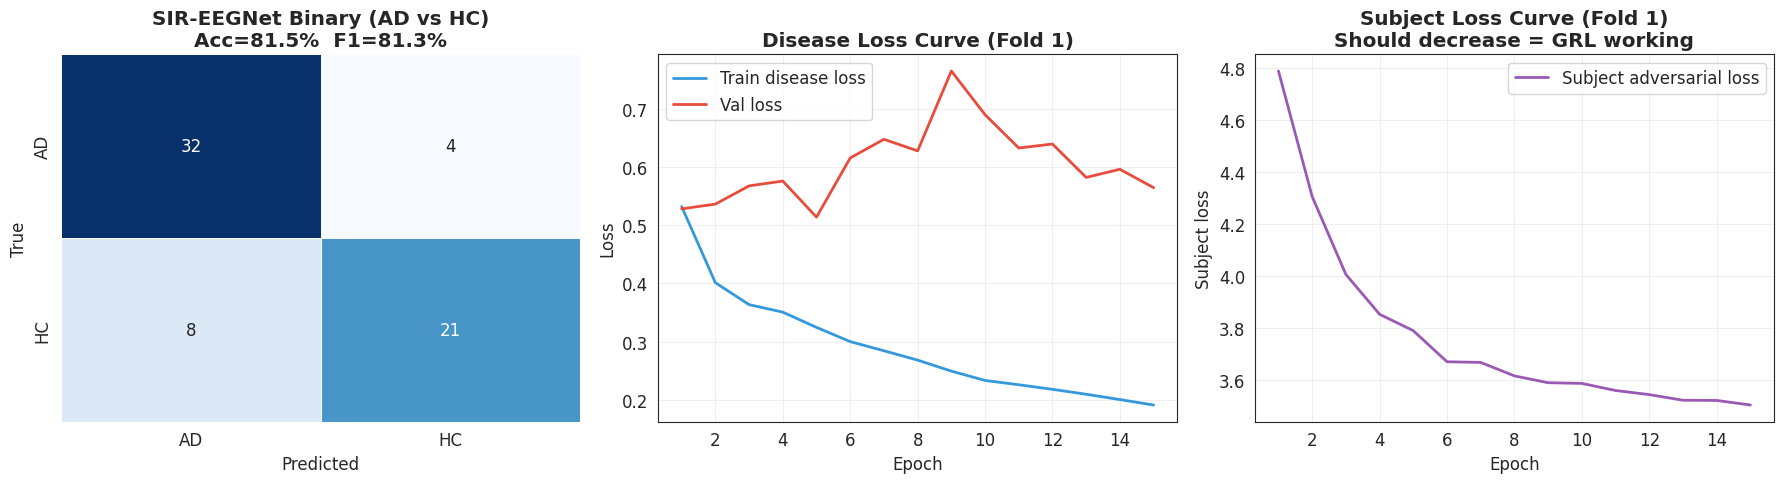

Saved: /content/sir-eegnet/results/fig_sir_eegnet_binary.png


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(results['true'], results['pred'], labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['AD', 'HC'], yticklabels=['AD', 'HC'],
            cbar=False, linewidths=0.5)
ax.set_title(f'SIR-EEGNet Binary (AD vs HC)\n'
             f'Acc={results["accuracy"]*100:.1f}%  '
             f'F1={results["f1_weighted"]*100:.1f}%',
             fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# Disease loss curve (fold 0)
ax2 = axes[1]
h   = results['histories'][0]
ep  = range(1, len(h['disease_loss']) + 1)
ax2.plot(ep, h['disease_loss'], label='Train disease loss',
          color='#3498DB', linewidth=2)
ax2.plot(ep, h['val_loss'],     label='Val loss',
          color='#E74C3C', linewidth=2)
ax2.set_title('Disease Loss Curve (Fold 1)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Subject loss curve (fold 0) — should decrease then plateau
ax3 = axes[2]
ax3.plot(ep, h['subject_loss'], label='Subject adversarial loss',
          color='#9B59B6', linewidth=2)
ax3.set_title('Subject Loss Curve (Fold 1)\n'
              'Should decrease = GRL working', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Subject loss')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
out_fig = RESULTS_DIR / 'fig_sir_eegnet_binary.png'
fig.savefig(str(out_fig), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

Cell 18a — Save results

In [20]:
summary = {
    'model':      'SIR-EEGNet (EEGNet + Gradient Reversal Layer)',
    'task':       'Binary AD vs HC',
    'evaluation': 'Subject-level LOSO + majority vote — zero leakage',
    'dataset':    'ds004504 (OpenNeuro, 88 subjects)',
    'hyperparams': {
        'grl_lambda': GRL_LAMBDA,
        'alpha':      ALPHA,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'patience':   PATIENCE,
        'max_ep_per_subject': MAX_EP_PER_SUBJECT,
    },
    'results': {
        'n_subjects':  len(results['subject_ids']),
        'accuracy':    round(float(results['accuracy']), 4),
        'f1_weighted': round(float(results['f1_weighted']), 4),
        'f1_macro':    round(float(results['f1_macro']), 4),
        'total_time_min': round(sum(results['fold_times']) / 60, 1),
        'mean_fold_time_s': round(float(np.mean(results['fold_times'])), 1),
    },
    'baselines': {
        'svm_rbp_loso':    0.8310,
        'eegnet_raw_loso': 0.7846,
    }
}

out_json = RESULTS_DIR / 'results_sir_eegnet_binary.json'
with open(out_json, 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'subject_id': results['subject_ids'],
    'true':       results['true'],
    'pred':       results['pred'],
    'correct':    (results['true'] == results['pred']).astype(int)
}).to_csv(str(RESULTS_DIR / 'sir_predictions_binary.csv'), index=False)

print('=== Notebook 05a Complete ===')
print()
print(f"Accuracy  : {summary['results']['accuracy']*100:.2f}%")
print(f"F1 (W)    : {summary['results']['f1_weighted']*100:.2f}%")
print(f"Time      : {summary['results']['total_time_min']} min")
print()
print(f'Saved: {out_json}')

=== Notebook 05a Complete ===

Accuracy  : 81.54%
F1 (W)    : 81.34%
Time      : 209.6 min

Saved: /content/sir-eegnet/results/results_sir_eegnet_binary.json


In [21]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# =============================
# Save metrics (JSON)
# =============================
metrics = {
    "accuracy": float(results["accuracy"]),
    "f1_weighted": float(results["f1_weighted"]),
    "f1_macro": float(results["f1_macro"]),
    "total_time_min": float(elapsed / 60)
}

with open("/kaggle/working/sir_eegnet_binary_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# =============================
# Save predictions (CSV)
# =============================
df_preds = pd.DataFrame({
    "y_true": results["true"],
    "y_pred": results["pred"]
})
df_preds.to_csv("/kaggle/working/sir_eegnet_binary_predictions.csv", index=False)

# =============================
# Save confusion matrix
# =============================
cm = confusion_matrix(results["true"], results["pred"])
np.save("/kaggle/working/sir_eegnet_binary_confusion.npy", cm)

# =============================
# Save classification report
# =============================
report = classification_report(
    results["true"], results["pred"],
    target_names=['AD', 'HC'],
    zero_division=0,
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    "/kaggle/working/sir_eegnet_binary_report.csv"
)

print("\n✅ All results saved to /kaggle/working/")


✅ All results saved to /kaggle/working/
